## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import msml610_utils as ut
ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux 589569fe8102 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [2]:
import os

import helpers.hio as hio
import L09_01_reasoning_over_time_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

# Cell 1: Estimating Body Weight

## Cell 1.1: Ground truth

In [3]:
n_samples = 12

# We assume we know the real weight.
ground_truth = 160.0 + np.arange(0, n_samples)

# This is what we measure.
measured_weights = np.array(
    [
        158.0,
        164.2,
        160.3,
        159.9,
        162.1,
        164.6,
        169.6,
        167.4,
        166.4,
        171.0,
        171.2,
        172.6,
    ]
)

idx = pd.date_range("2011-01-01", periods=len(measured_weights))
df = pd.DataFrame(measured_weights.T, index=idx, columns=["measurements"])
df["ground_truth"] = ground_truth

df.head()

,measurements,ground_truth
2011-01-01,158.0,160.0
2011-01-02,164.2,161.0
2011-01-03,160.3,162.0
2011-01-04,159.9,163.0
2011-01-05,162.1,164.0


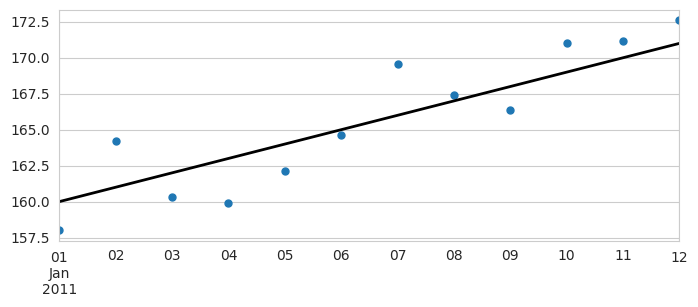

In [4]:
df["measurements"].plot(marker=".", markersize=10, linestyle="None");
df["ground_truth"].plot(color="k", linewidth=2);

plt.savefig(os.path.join(dst_dir, "L09_04_ground_truth.png"))

## Cell 1.2: Knowing gain_rate

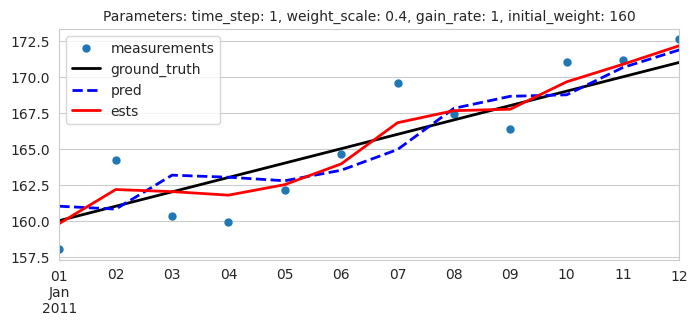

In [5]:
params = {
    # This is the time interval between measurements
    "time_step": 1,
    # This is the blending factor
    "weight_scale": 4 / 10.0,
    # This is the internal model (ground truth)
    "gain_rate": 1.0,
    # This is the initial weight
    "initial_weight": 160.0,
}
file_name = "L09_04_knowing_gain_rate.png"
time_ut.cell1_2_plot_gh_filter_with_known_gain_rate(measured_weights, ground_truth, params, dst_dir, file_name)

## Cell 1.3: Wrong guess of gain_rate

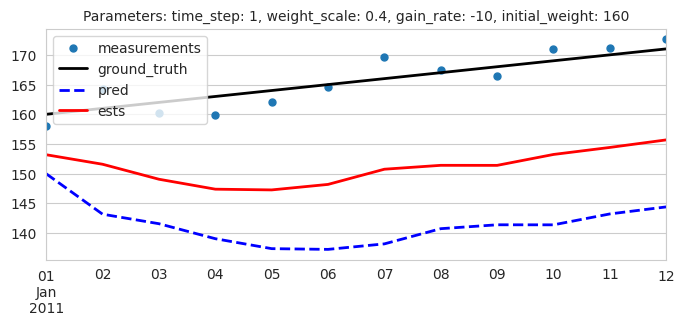

In [6]:
params = {
    # This is the time interval between measurements
    "time_step": 1,
    # This is the blending factor
    "weight_scale": 4 / 10.0,
    # This is the internal model (wrong guess)
    "gain_rate": -10.0,
    # This is the initial weight
    "initial_weight": 160.0,
}
file_name = "L09_04_wrong_gain_rate.png"
time_ut.cell1_3_plot_gh_filter_with_known_gain_rate(measured_weights, ground_truth, params, dst_dir, file_name)

## Cell 1.4: Interactive

In [7]:
# Interactive exploration of gain rate parameters.
time_ut.cell1_4_create_interactive_gain_rate_widget(measured_weights, ground_truth)

## Cell 1.5: Learning gain_rate

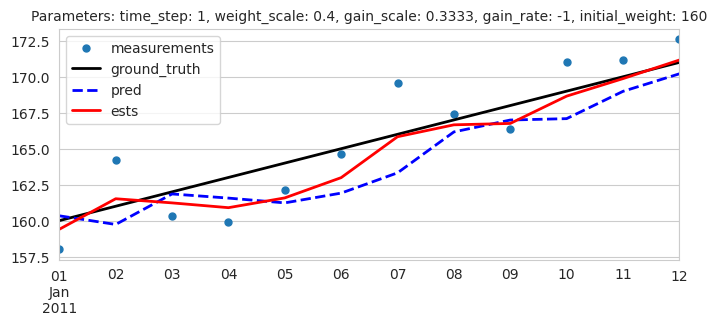

In [8]:
params = {
    # Time interval between measurements
    "time_step": 1,
    # Scale for updating the weight estimate (blending factor)
    "weight_scale": 4 / 10.0,
    # Scale for updating the gain rate estimate
    "gain_scale": 1 / 3.0,
    # Initial guess for the gain rate
    "gain_rate": -1.0,
    # Initial value for weight estimate
    "initial_weight": 160.0,
}
file_name = "L09_04_learning_gain_rate.png"

time_ut.cell1_5_plot_gh_filter_with_learning_gain_rate(measured_weights, ground_truth, params, dst_dir, file_name)

# Cell 2: g-h Filter on Noisy measurements

## Cell 2.1: Interactive Linear Noisy Data

In [19]:
# Interactive exploration of linear noisy data generation parameters.
time_ut.cell2_1_create_interactive_linear_noisy_data_widget()

## Cell 2.2: Correct Initial Guess

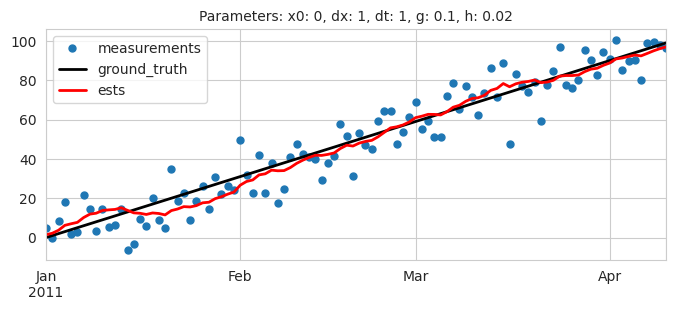

In [10]:
# Demonstrate g-h filter with correct initial guesses.
params = {
    # Initial guesses (actually correct!).
    "x0": 0,
    "dx": 1,
    "dt": 1,
    "g": 0.1,
    "h": 0.02,
}
time_ut.cell2_2_plot_gh_filter_with_params(params)

## Cell 2.3: Wrong Initial Guess

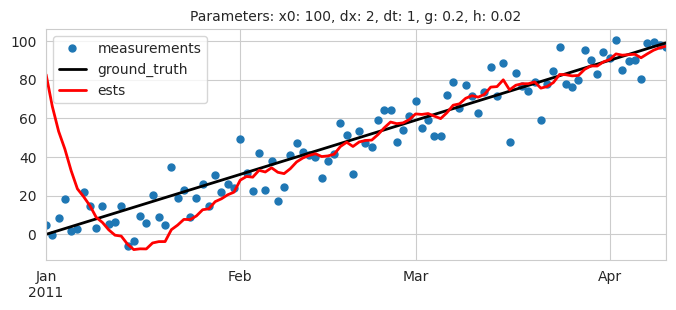

In [11]:
# Demonstrate g-h filter with wrong initial guesses.
params = {
    # Initial guesses (wrong!).
    "x0": 100,
    "dx": 2,
    "dt": 1,
    "g": 0.2,
    "h": 0.02,
}
time_ut.cell2_3_plot_gh_filter_with_params(params)

## Cell 2.4: Extreme Noise

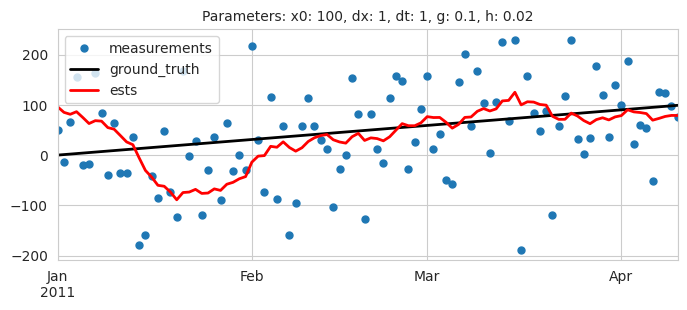

In [12]:
# Demonstrate g-h filter performance with extreme noise.
time_ut.cell2_4_extreme_noise()

## Cell 2.5: Interactive Non-Linear Noisy Data

In [20]:
# Interactive exploration of non-linear noisy data generation parameters.
time_ut.cell2_5_create_interactive_non_linear_noisy_data_widget()

## Cell 2.6: Non-Linear with g-h Filter

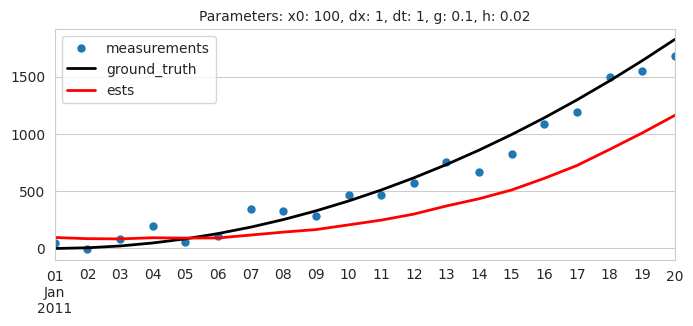

In [14]:
# Demonstrate g-h filter on non-linear data.
time_ut.cell2_6_non_linear_gh_filter()

## Cell 2.7: Varying g

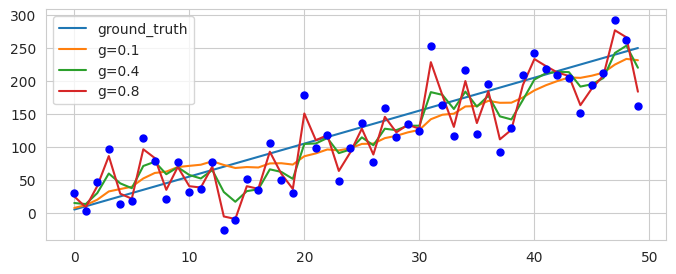

In [21]:
# If g is smaller we follow more our model than the measurements.
# If g is larger we follow more the measurements than our model
# If g is too large we follow the measurements and reject no noise.
np.random.seed(100)
zs, ground_truty = time_ut.gen_linear_noisy_data(
    x0=5, dx=5, count=50, noise_factor=50
)
df = pd.DataFrame(zs)
df.columns = ["measures"]

df["ground_truth"] = ground_truty
df["g=0.1"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.1, h=0.01)
df["g=0.4"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.4, h=0.01)
df["g=0.8"] = time_ut.gh_filter(data=zs, x0=0.0, dx=5.0, dt=1.0, g=0.8, h=0.01)

df.drop("measures", axis=1).plot()
df["measures"].plot(
    marker=".",
    markersize=10,
    color="b",
    # Hide line.
    linestyle="None",
)
plt.savefig(os.path.join(dst_dir, "L09_04_varying_g1.png"))

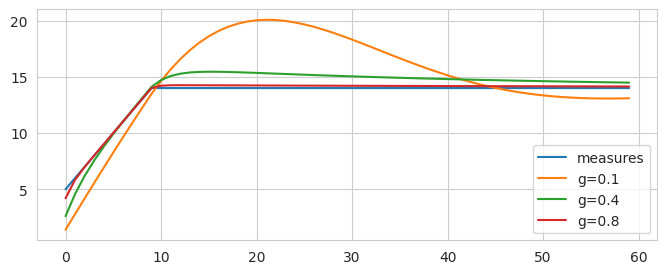

In [22]:
# If g is large we follow more the measures than our model.
zs = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
for i in range(50):
    zs.append(14)
df = pd.DataFrame(zs)
df.columns = ["measures"]

df["g=0.1"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.1, h=0.01)
df["g=0.4"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.4, h=0.01)
df["g=0.8"] = time_ut.gh_filter(data=zs, x0=0.0, dx=1, dt=1.0, g=0.8, h=0.01)

df.plot();
plt.savefig(os.path.join(dst_dir, "L09_04_varying_g2.png"))

## Cell 2.8: Varying h
- h affects how much we favor the measurement of $\frac{dx}{dt}$ vs our prediction
- If the signal is varying a lot, then we will react to the transient rapidly

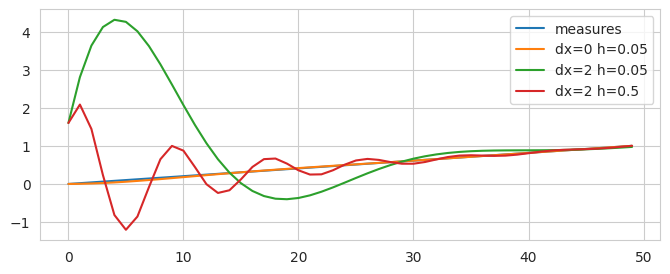

In [23]:
# Go from 0 to 1 in 50 steps (dx = 1 / 50 = 0.02) without noise.
zs = np.linspace(0, 1, 50)
df = pd.DataFrame(zs)
df.columns = ["measures"]

# dx is close to ground truth with small h.
# We track the signal right.
df["dx=0 h=0.05"] = time_ut.gh_filter(data=zs, x0=0, dx=0, dt=1.0, g=0.2, h=0.05)

# dx is wrong, with small h.
# There is big ringing, and we adapt slowly (lower frequency).
df["dx=2 h=0.05"] = time_ut.gh_filter(data=zs, x0=0, dx=2, dt=1.0, g=0.2, h=0.05)

# dx is wrong, with large h.
# Small ringing with higher frequency.
df["dx=2 h=0.5"] = time_ut.gh_filter(data=zs, x0=0, dx=2, dt=1.0, g=0.2, h=0.5)

df.plot();
plt.savefig(os.path.join(dst_dir, "L09_04_varying_h1.png"))

## Cell 2.9: Interactive g-h Filter Example

In [18]:
# Interactive exploration of g-h filter parameters.
time_ut.cell2_9_create_interactive_gh_filter_widget()

# Cell 3: Sum and Product of Gaussians

## Cell 3.1: Sum of Gaussians
- Given two Gaussians $X$ and $Y$
  - $X \sim Normal(\mu_1, \sigma_1^2)$
  - $Y \sim Normal(\mu_2, \sigma_2^2)$
- For correlated Gaussians with correlation coefficient $\rho$, the sum $Z = X + Y$ is a Gaussian $Normal(\mu, \sigma^2)$ with:
  - $\mu = \mu_1 + \mu_2$
  - $\sigma^2 = \sigma_1^2 + \sigma_2^2 + 2\rho\sigma_1\sigma_2$
- **Interpretation:**
  - The mean is the sum of the means (by linearity)
  - For independent Gaussians ($\rho = 0$), the variance is the sum of variances
  - Positive correlation increases variance, negative correlation decreases it

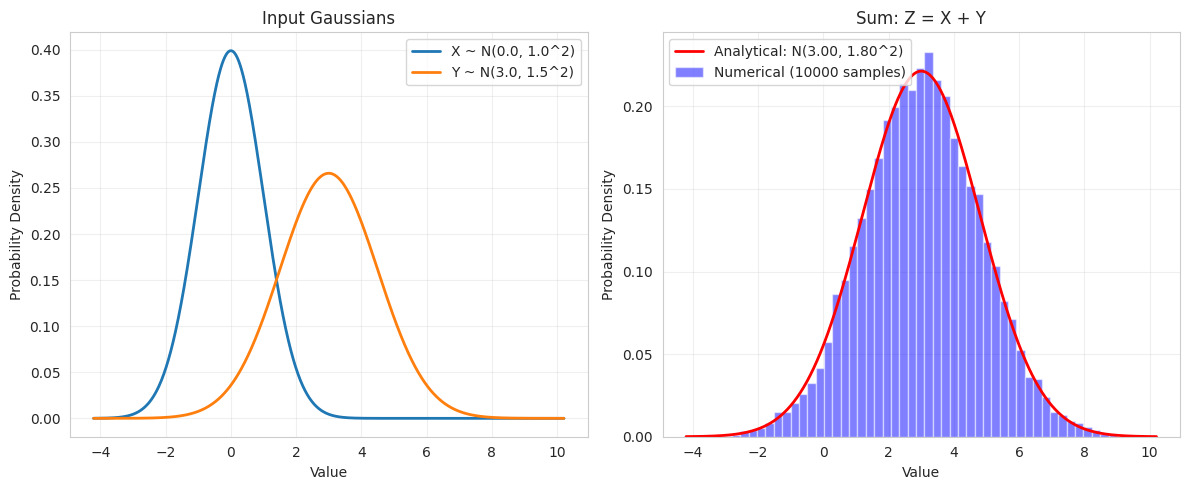

In [24]:
# Interactive exploration of sum of Gaussians with correlation.
time_ut.cell3_1_plot_gaussian_sum()

## Cell 3.2: Product of Gaussians
- Given two Gaussians $X$ and $Y$
  - $X \sim Normal(\mu_1, \sigma_1^2)$
  - $Y \sim Normal(\mu_2, \sigma_2^2)$
- The product $Z = X \cdot Y$ (PDF multiplication) is a Gaussian $Normal(\mu, \sigma^2)$ with:
  - $\mu = \frac{\mu_1 \sigma_2^2 + \mu_2 \sigma_1^2}{\sigma_1^2 + \sigma_2^2}$
  - $\sigma^2 = \frac{\sigma_1^2 \sigma_2^2}{\sigma_1^2 + \sigma_2^2}$
- **Interpretation:**
  - Reduces variance by incorporating more information
  - If one Gaussian $X$ is narrower (more accurate), result leans towards $X$
  - If two Gaussians are similar (measures corroborate), result becomes more certain

In [ ]:
# Interactive exploration of product of Gaussians.
time_ut.cell3_2_plot_gaussian_product()